<a href="https://colab.research.google.com/github/gavinathaya/KleoProj/blob/main/abad_elippe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproduce Abad, Elippe, Ferreira 2024

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from astropy import units as u, constants as cons

The equation of motion

$\ddot x - 2\dot y = x - \frac{1}{\omega^2} \partial U/ \partial x = \partial \Omega/\partial x$

$\ddot y - 2\dot x = y - \frac{1}{\omega^2} \partial U/ \partial y = \partial \Omega/\partial y$

$\ddot z = - \frac{1}{\omega^2} \partial U/\partial z = \partial \Omega/\partial z$


$\Omega$ is defined as the effective potential

$\Omega = \frac{1}{2} (x^2 + y^2) - \frac{1}{\omega^2}U$
$= \frac{1}{2} (x^2 + y^2) + \kappa (\frac{(1-\mu)(1-\mu_s)}{r_1} + \frac{\mu(1-\mu_s)}{r_2}) + \mu_s \log[\frac{(r_1 + r_2 + 1)}{(r_1 + r_2 - 1)}]$


where $\kappa = \frac{1}{\omega^2} \frac{GM}{l^2}$


$\ddot x - 2\dot y = \partial \Omega/\partial x = \frac{\kappa(1-\mu_s)}{2} \left(\frac{(x+l_1)}{r_1^3} + \frac{(x-l_2)}{r_2^3} \right) - \left( 1 - \frac{2\kappa \mu_s}{s p}\right) x$

$\ddot y - 2\dot x = \partial \Omega/\partial y$ = $\frac{\kappa(1-\mu_s)}{2} \left(\frac{1}{r_1^3} + \frac{1}{r_2^3} \right) - \left( 1 - \frac{2\kappa \mu_s}{(s^2 -1) p}\right) y$

$\ddot z = \partial \Omega/\partial z$ = $\kappa \left[\frac{(1-\mu_s)}{2} \left(\frac{1}{r_1^3} + \frac{1}{r_2^3} \right) + \frac{2\kappa \mu_s}{(s^2 -1) p}\right] z$

In [ ]:
def potential(x, y, z, l1, l2, kappa):

    # M = m1 + m2 + ms
    # mu = m2/(m1+m2)
    # mu_s = ms/M
    G = cons.G.value
    M = ms/mu_s
    leng = l1 + l2
    r1 = np.sqrt((x + l1)**2 + y**2 + z**2)
    r2 = np.sqrt((x - l2)**2 + y**2 + z**2)

    # kappa = 1/(omega**2) * G * M /leng**3

    res = -1 * kappa * omega**2 * ((1-mu)*(1-mu_s)/r1 + mu*(1-mu_s)/r2 + mu_s * np.log((r1 + r2 + 1)/(r1 + r2 - 1)))
    return res

def eff_potential(x, y, z, l1, l2, kappa):

    # M = m1 + m2 + ms
    # mu = m2/(m1+m2)
    # mu_s = ms/M
    G = cons.G.value

    r1 = np.sqrt((x + l1)**2 + y**2 + z**2)
    r2 = np.sqrt((x - l2)**2 + y**2 + z**2)
    leng = l1 + l2
    # kappa = 1/(omega**2) * G * M /leng**3

    res1 = 0.5 * (x**2 + y**2)

    res2 = kappa * ((1-mu)*(1-mu_s)/r1 + mu*(1-mu_s)/r2 + mu_s * np.log((r1 + r2 + 1)/(r1 + r2 - 1)))
    return res1 + res2

def limit_ellips(x, y, a, b):
    val = x**2/a**2 + y**2/b**2
    return val


def rotating_aster(t, Y):

    # print(s.shape, p.shape, d.shape)

    x, y, z = Y[:3]
    r1 = np.sqrt((x + l1)**2 + y**2 + z**2)
    r2 = np.sqrt((x - l2)**2 + y**2 + z**2)


    s = r1 + r2
    p = r1 * r2
    d = r1 - r2

    xdot, ydot, zdot = Y[3:]
    Ydot = np.zeros_like(Y)
    Ydot[:3] = Y[3:]


    Ydot[3] = 2*ydot + (kappa*(1-mu_s)/2 * ((x + l1)/(r1**3) + (x - l2)/(r2**3)) - (1 - 2*kappa*mu_s/(s * p)) * x) ## \ddot x
    Ydot[4] = - 2*xdot + (kappa * (1-mu_s)/2 * (1/r1**3 + 1/r2**3) - (1 - 2*kappa*mu_s*s/((s**2 - 1)*p))) * y  ## \ddot y
    Ydot[5] = kappa * ( (1-mu_s)/2 * (1/r1**3 + 1/r2**3) + 2 * kappa * mu_s * s/((s**2 - 1)*p)) * z ## \ddot z
    # print(Ydot)
    return Ydot
    # else:
    #     pass

def aster_solver(t0, tf, tpoints):
    # print("t0, tf",t0, tf)
    sol = solve_ivp(rotating_aster, [t0, tf], Y0, t_eval=tpoints, rtol=2.5e-14, atol=1e-22)
    Y = sol.y.T
    return Y

def crossing(r):
    soly = r[:,1]
    crossing = []
    for i in range(len(soly)-1):
        # print(soly[i])
        if (soly[i] < 0) and (soly[i+1] > 0):
            # print('yey')
            crossing.append([r[:,0][i], v[:,0][i]])
        if (soly[i] > 0) and (soly[i+1] < 0):
            crossing.append([r[:,0][i], v[:,0][i]])
    crossing = np.array(crossing)
    return crossing

def objective(Y0):
    sol = solve_ivp(rotating_aster, [t0, tf], Y0, t_eval=tpoints, atol=1e-10, rtol=1e-8)
    Yf = sol.y[:,-1]
    return Yf - Y0


# Potential and Effective Potential

(-2.0, 2.0)

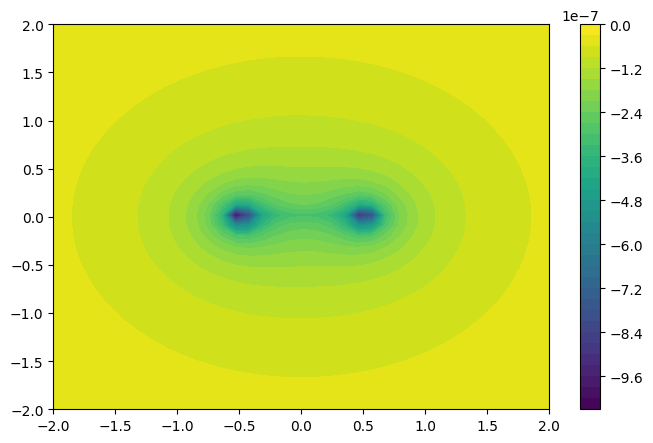

In [ ]:
# # m1 = 1.1014e18
# # m2 = 1.0350e18
ms = 4.1547e17

mu = 0.484
mu_s = 0.163
l = 117800.0
l1 = 0.486608
l2 = 0.513392
kappa = 0.991
period = 5.385 * u.hour
omega = (2*np.pi/period).to(u.rad/u.s, equivalencies=u.dimensionless_angles())
omega = omega.value
# eff_potential(0, 0, 0, 100, 100, 10)

# Effective Potential
fig, ax = plt.subplots(figsize=(8, 5))

x_arr = np.arange(-3.500, 3.500, 0.11)
y_arr = np.arange(-3.500, 3.500, 0.11)

x_mat, y_mat = np.meshgrid(x_arr, y_arr)

# eff_potential(x, y, z, l1, l2, omega)

effective_surf = potential(x_mat, y_mat, np.zeros_like(x_mat), l1, l2, kappa)


surf = ax.contourf(x_mat, y_mat, effective_surf, 35)


fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)




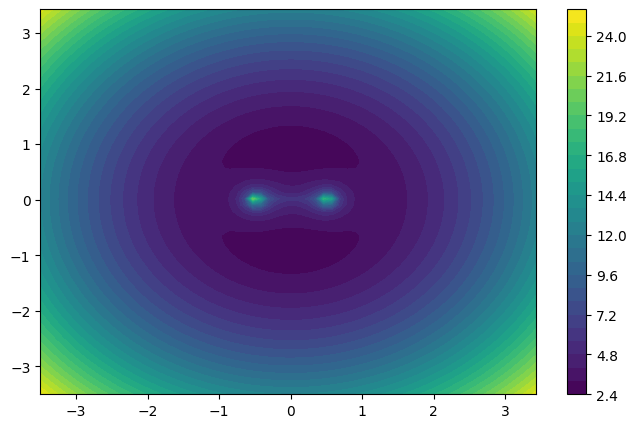

In [ ]:
ms = 4.1547e17

mu = 0.484
mu_s = 0.163
l = 117800.0
l1 = 0.486608
l2 = 0.513392
kappa = 0.991
period = 5.385 * u.hour
omega = (2*np.pi/period).to(u.rad/u.s, equivalencies=u.dimensionless_angles())
omega = omega.value
# eff_potential(0, 0, 0, 100, 100, 10)

# Effective Potential
fig, ax = plt.subplots(figsize=(8, 5))

x_arr = np.arange(-3.500, 3.500, 0.11)
y_arr = np.arange(-3.500, 3.500, 0.11)

x_mat, y_mat = np.meshgrid(x_arr, y_arr)

# eff_potential(x, y, z, l1, l2, omega)

effective_surf = 2 * eff_potential(x_mat, y_mat, np.zeros_like(x_mat), l1, l2, kappa)


surf = ax.contourf(x_mat, y_mat, effective_surf, 35)


fig.colorbar(surf)



# Solve Trajectory

In [ ]:
def jacobi_const(x, y, z, l1, l2, kappa, vx, vy, vz):
    res = 2 * eff_potential(x, y, z, l1, l2, kappa) - (vx**2 + vy**2 + vz**2)
    return res

def vy_init(x, y, z, l1, l2, kappa, C):
    res = np.sqrt(2 * eff_potential(x, y, z, l1, l2, kappa)- C)
    return res

In [ ]:
# From Abad & Elippe
Lag1 = [-1.176968,0]
Lag2 = [1.185509,0]
Lag3 = [0.012333,0.882277]
Lag4 = [0.0123333,-0.92277]

In [ ]:
print(jacobi_const(-1.176968,0, 0, l1, l2, kappa, 0, 0, 0))

print(jacobi_const(1.185509,0, 0, l1, l2, kappa, 0, 0, 0))

print(jacobi_const(0.012333,0.882277, 0, l1, l2, kappa, 0, 0, 0))

print(jacobi_const(0.0123333,-0.882277, 0, l1, l2, kappa, 0, 0, 0))

3.3895029791591202
3.406429568866086
2.7634082529122646
2.7634082529121886


The values of the Jacobi Constants (zero velocity curve) are the same as Abad & Elippe 2024.

In [ ]:
# Shooting Method

# Time points
period = 1
t0, tf = 0, 10
tpoints = np.linspace(t0, tf, 100)

x0, y0, z0, vx0, vy0, vz0 = -1.176968, 0, 0, 0, 0, 0

Y0_guess = [x0, y0, z0, vx0, vy0, vz0]
print(len(Y0_guess))
sol_params = fsolve(objective, Y0_guess)

sol_params

6


array([-1.17079196e+00, -3.68065434e-10, -5.91257108e-12, -1.77448371e-10,
        2.42940612e-10,  7.30442010e-12])

# Reproduce some trajectories from Abad, et.al 2024

# m-class

Text(0.5, 1.0, '$x0$ = -0.614568, $vy_0 = 3.0140321525069935$, $C_j = $-0.60205')

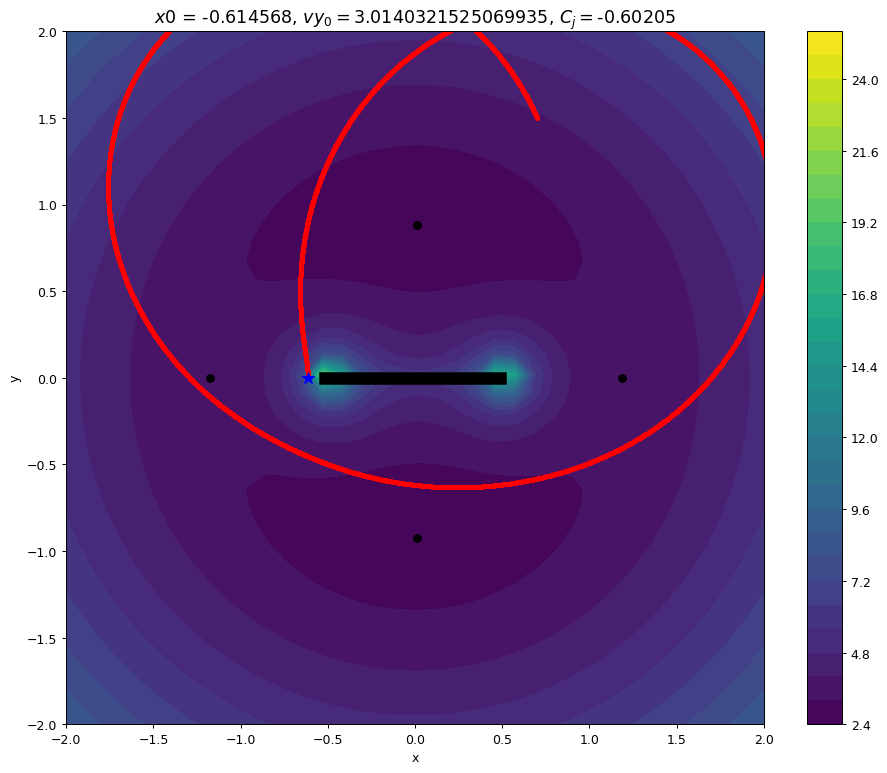

In [ ]:
#initial conditions
x0, y0, z0 = -0.614568, 0, 0
vx0, vy0, vz0 = 0, vy_init(x0, y0, z0, l1, l2, kappa, -0.602054), 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 4
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12.5,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)


ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.5f}', fontsize = 14)

# l-class

Text(0.5, 1.0, '$x0$ = -1.883784, $vy_0 = 1.1820067240056253$, $C_j = $3.27352')

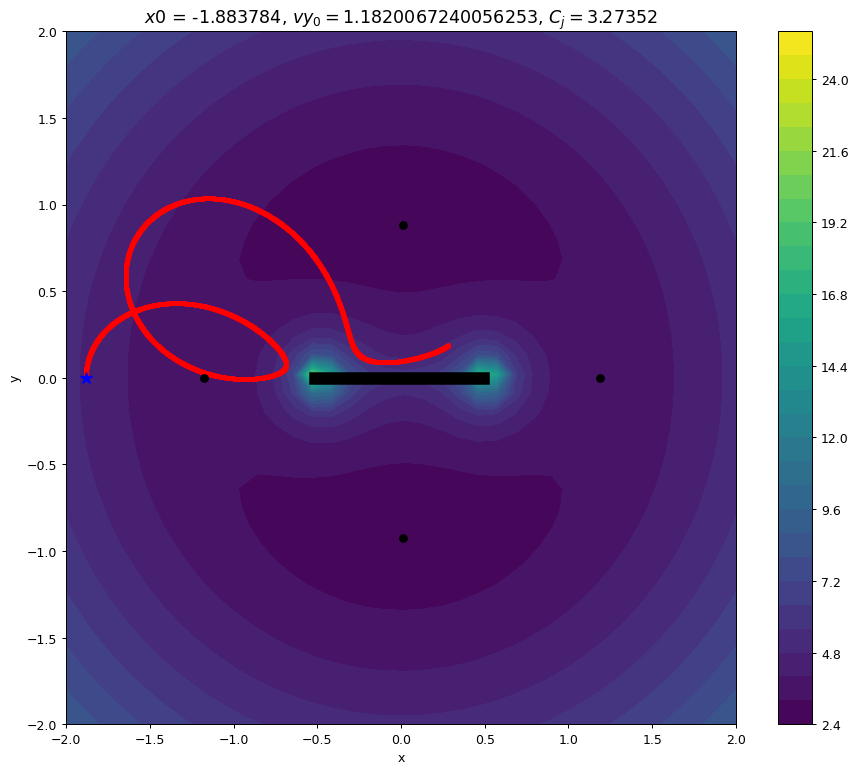

In [ ]:
#initial conditions
x0, y0, z0 = -1.883784, 0, 0
vx0, vy0, vz0 = 0, vy_init(x0, y0, z0, l1, l2, kappa, 3.273523), 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 4
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)


ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.5f}', fontsize = 14)

# b-class

Text(0.5, 1.0, '$x0$ = -1.724056, $vy_0 = 1.4526253841614742$, $C_j = $2.10421')

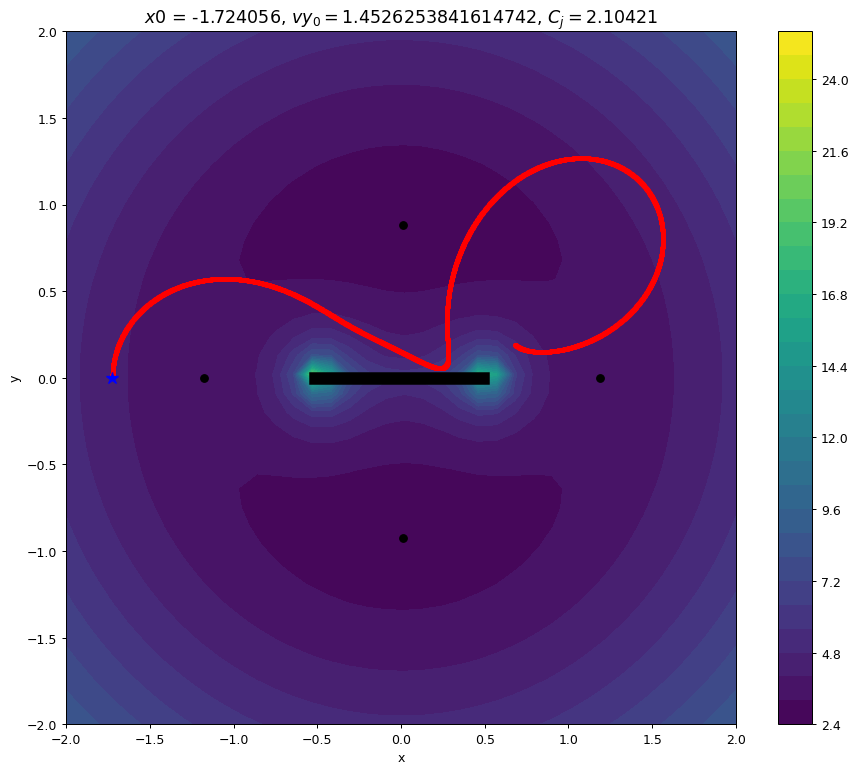

In [ ]:
#initial conditions
x0, y0, z0 = -1.724056, 0, 0
vx0, vy0, vz0 = 0, vy_init(x0, y0, z0, l1, l2, kappa, 2.104207), 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 4
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)
fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)


ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.5f}', fontsize = 14)

Text(0.5, 1.0, '$x0$ = -1.783933, $vy_0 = 1.518110306566561$, $C_j = $2.07170')

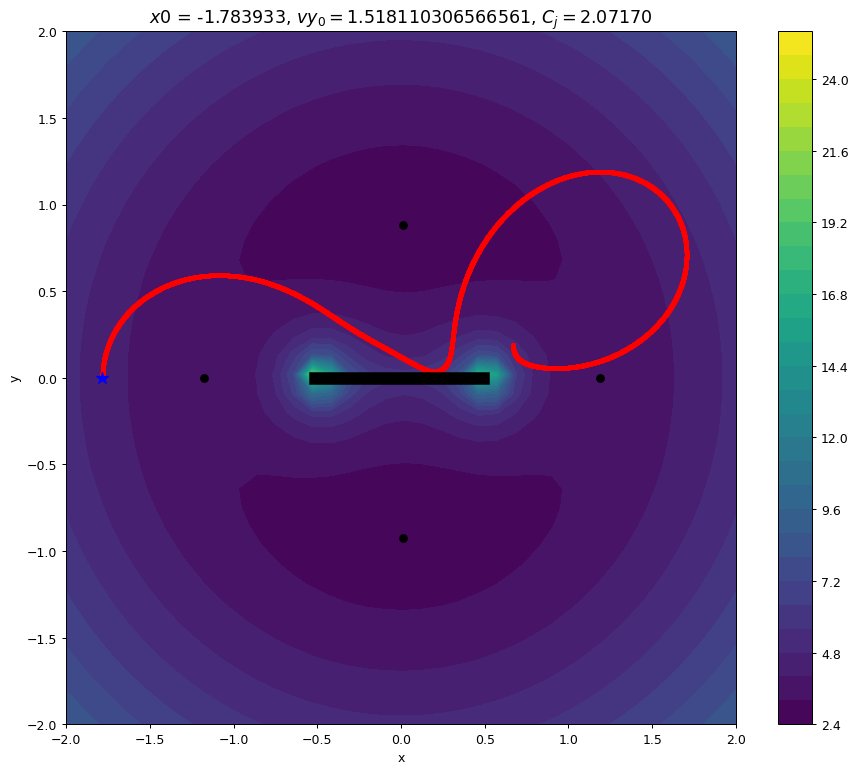

In [ ]:
#initial conditions
x0, y0, z0 = -1.783933, 0, 0
vx0, vy0, vz0 = 0, vy_init(x0, y0, z0, l1, l2, kappa, 2.071702), 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 4
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)
fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)


ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.5f}', fontsize = 14)

# a-class

Text(0.5, 1.0, '$x0$ = 0.554386, $vy_0 = 4.433890056775283$, $C_j = $2.10160')

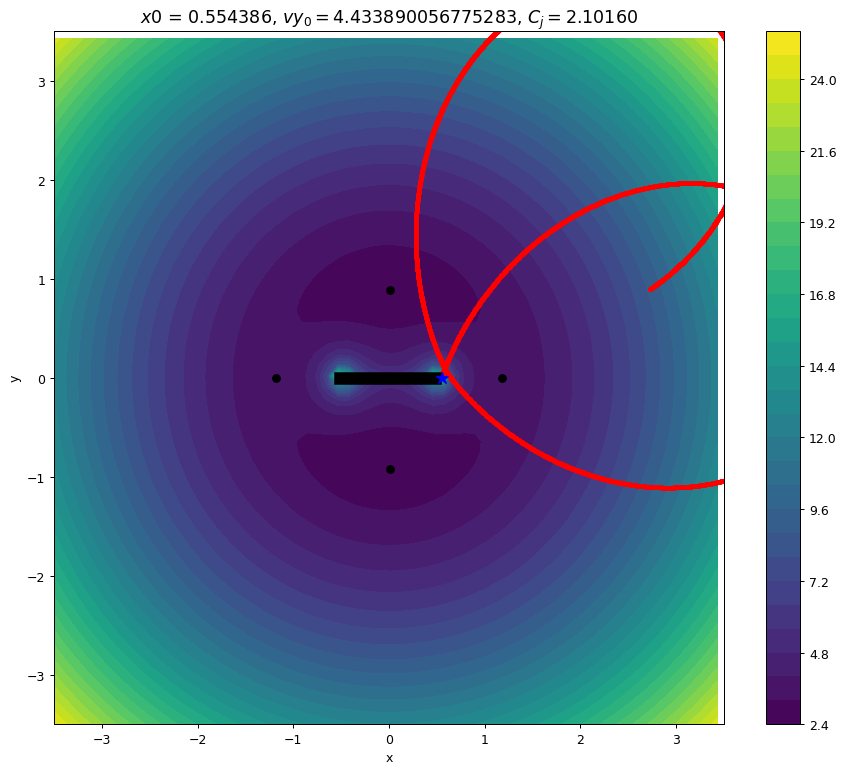

In [ ]:
#initial conditions
x0, y0, z0 = 0.554386, 0, 0
vx0, vy0, vz0 = 0, vy_init(x0, y0, z0, l1, l2, kappa, 2.101602), 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 4
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)
fig.colorbar(surf)


ax.set_xlim(-3.5,3.5)
ax.set_ylim(-3.5,3.5)


ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.5f}', fontsize = 14)

Text(0.5, 1.0, '$x0$ = 0.571144, $vy_0 = 3.7211542056875446$, $C_j = $2.13085')

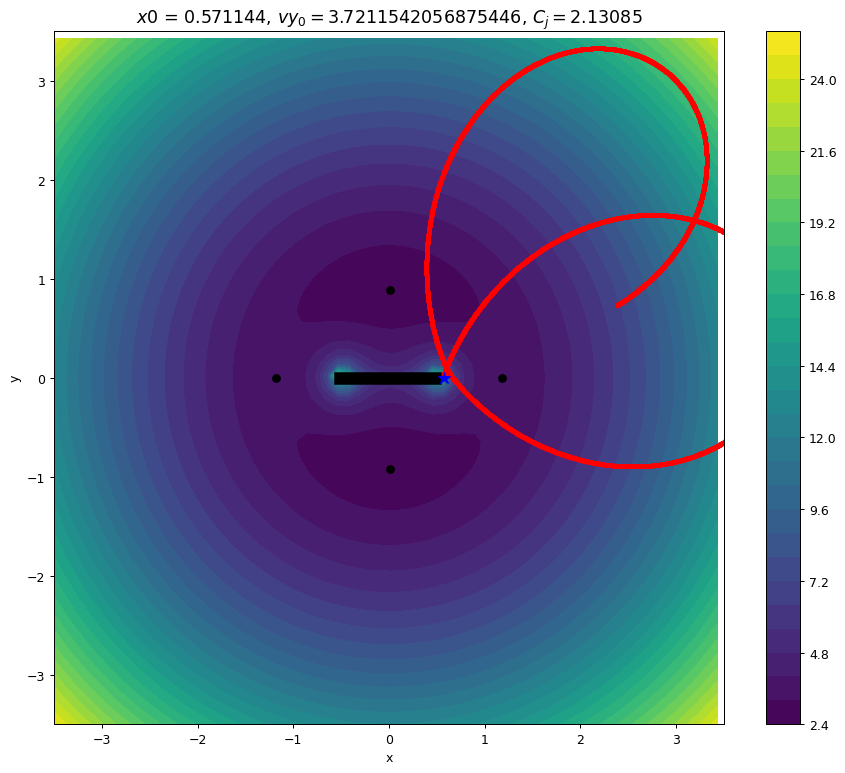

In [ ]:
#initial conditions
x0, y0, z0 = 0.571144, 0, 0
vx0, vy0, vz0 = 0, vy_init(x0, y0, z0, l1, l2, kappa, 2.130848), 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 4
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-3.5,3.5)
ax.set_ylim(-3.5,3.5)


ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.5f}', fontsize = 14)

# k-class

Text(0.5, 1.0, '$x0$ = 0.545702, $vy_0 = 4.854387373165723$, $C_j = $3.53173')

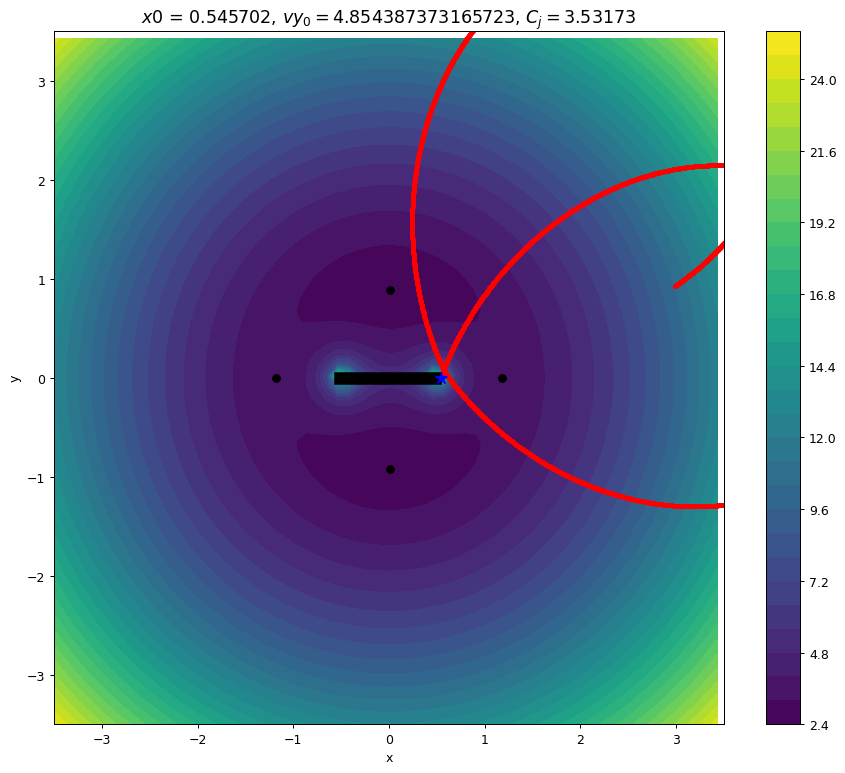

In [ ]:
#initial conditions
x0, y0, z0 = 0.545702, 0, 0
vx0, vy0, vz0 = 0, vy_init(x0, y0, z0, l1, l2, kappa, 3.531726), 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 4
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-3.5,3.5)
ax.set_ylim(-3.5,3.5)


ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.5f}', fontsize = 14)

Text(0.5, 1.0, '$x0$ = 0.569123, $vy_0 = 3.6087398724113156$, $C_j = $3.46914')

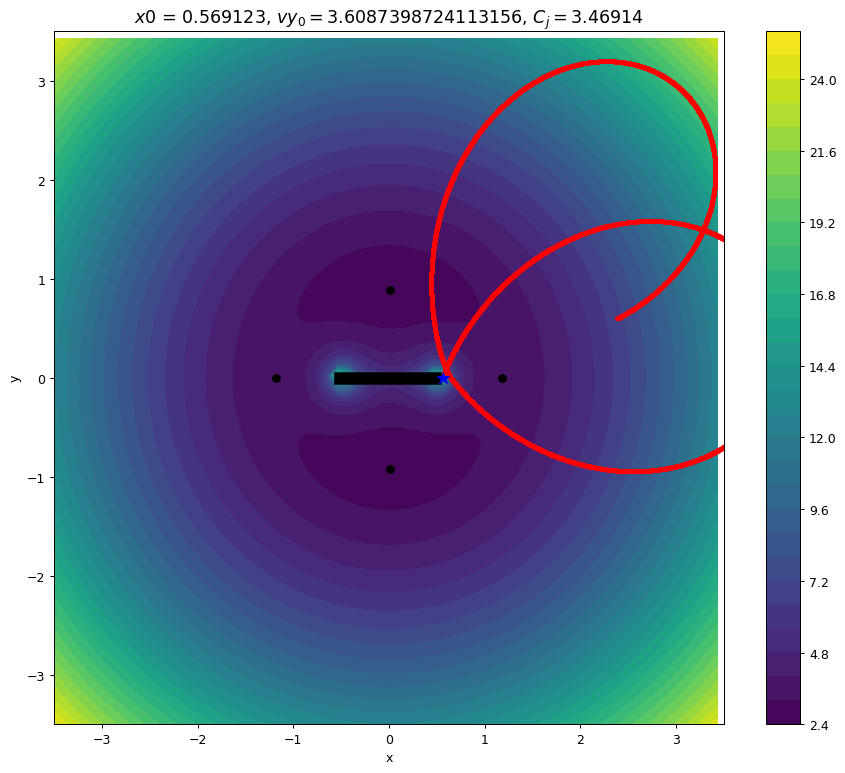

In [ ]:
#initial conditions
x0, y0, z0 = 0.569123, 0, 0
vx0, vy0, vz0 = 0, vy_init(x0, y0, z0, l1, l2, kappa, 3.469138), 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 4
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-3.5,3.5)
ax.set_ylim(-3.5,3.5)


ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.5f}', fontsize = 14)

# Arbitrary Points

Text(0.5, 1.0, '$x0$ = -1.17079196, $vy_0 = 2.5$, $C_j = $-2.860e+00')

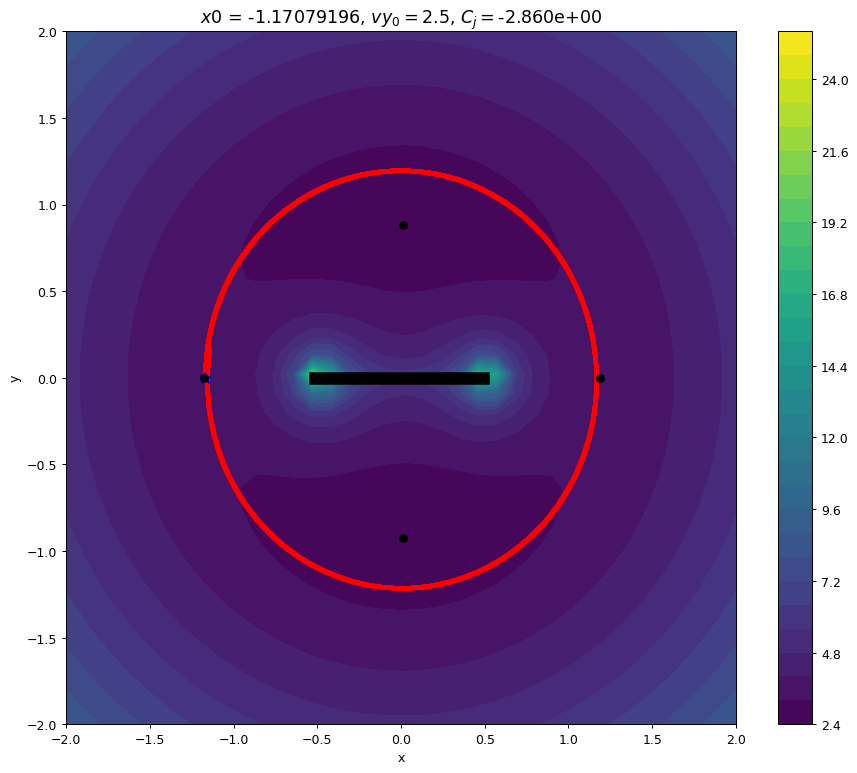

In [ ]:
#initial conditions
x0, y0, z0 = -1.17079196, 0, 0
vx0, vy0, vz0 = 0, 2.5, 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 3
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.3e}', fontsize = 14)

Text(0.5, 1.0, '$x0$ = -1.5, $vy_0 = 0.55$, $C_j = $3.413e+00')

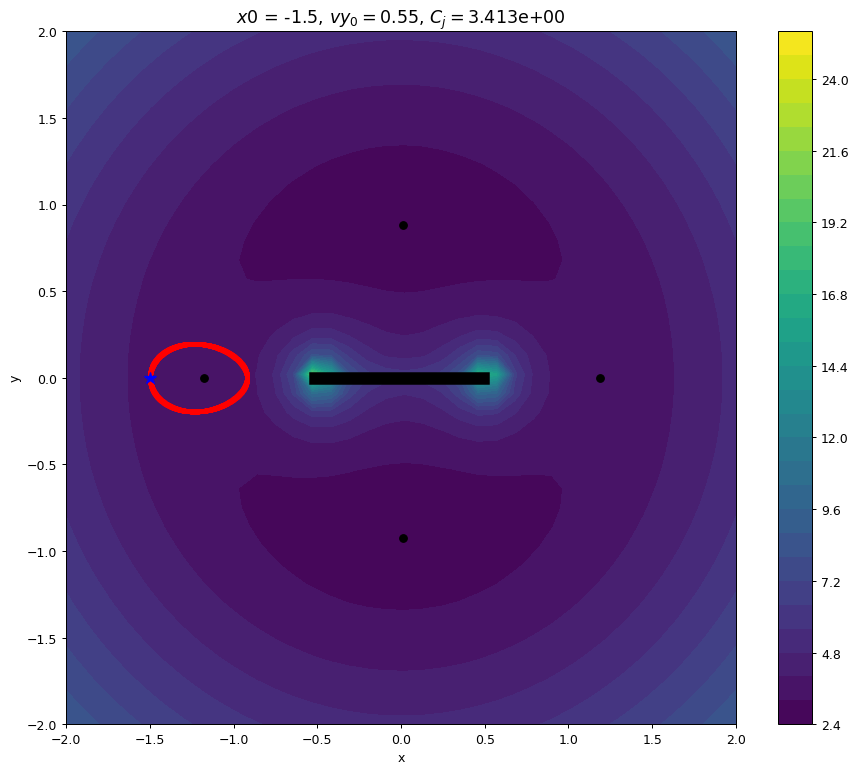

In [ ]:
#initial conditions
x0, y0, z0 = -1.5, 0, 0
vx0, vy0, vz0 = 0, 0.55, 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 5
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.3e}', fontsize = 14)

Text(0.5, 1.0, '$x0$ = -1.5, $vy_0 = -0.055$, $C_j = $3.712e+00')

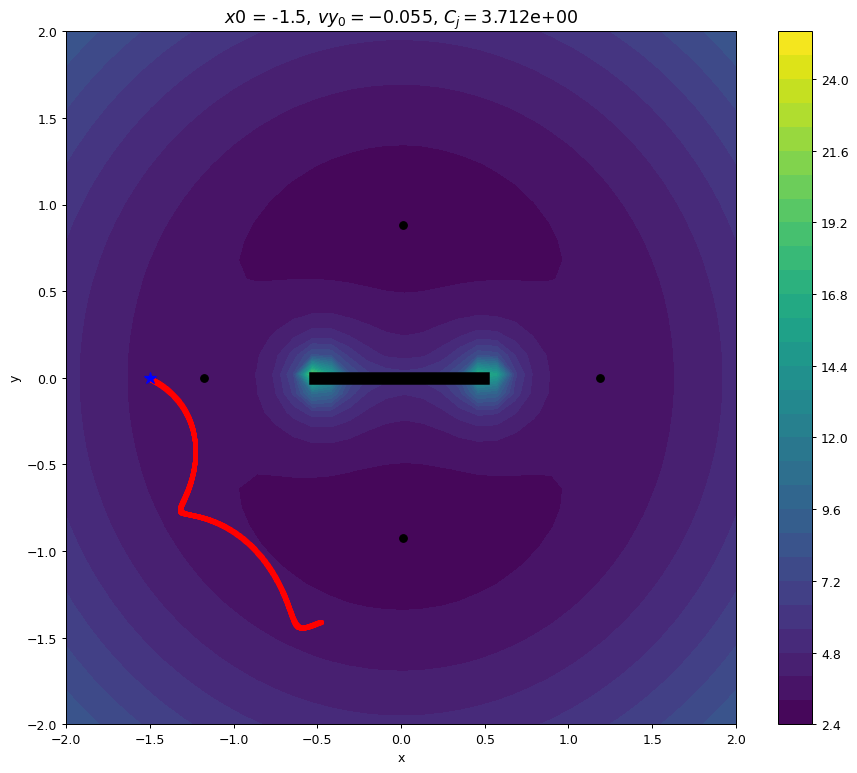

In [ ]:
#initial conditions
x0, y0, z0 = -1.5, 0, 0
vx0, vy0, vz0 = 0, -0.055, 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 5
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.3e}', fontsize = 14)

Text(0.5, 1.0, '$x0$ = -1.8, $vy_0 = 4.2$, $C_j = $-1.322e+01')

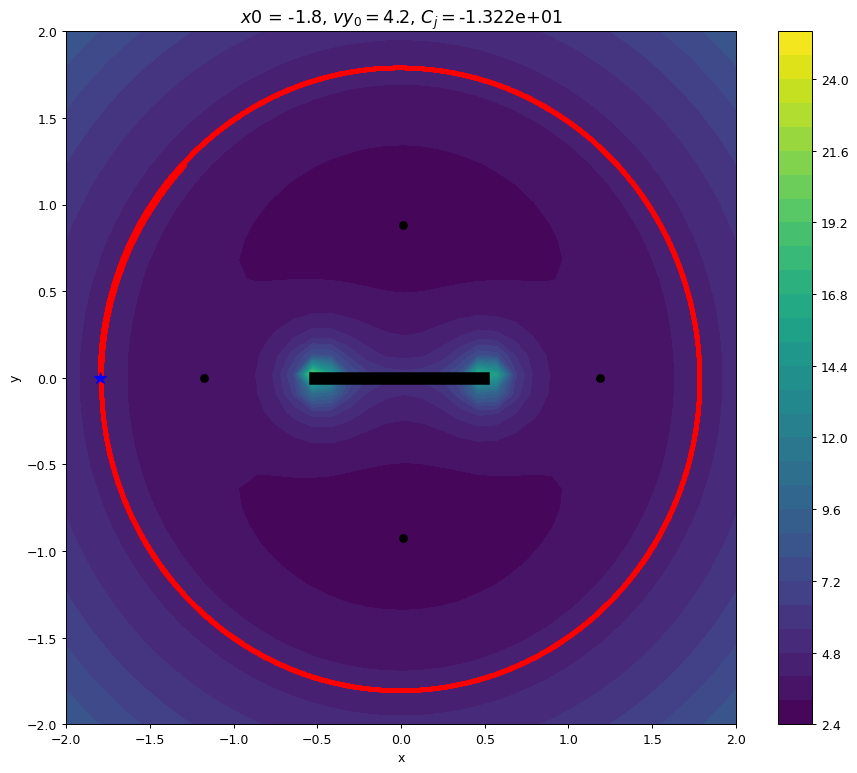

In [ ]:
#initial conditions
x0, y0, z0 = -1.8, 0, 0
vx0, vy0, vz0 = 0, 4.2, 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 3
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.3e}', fontsize = 14)

Text(0.5, 1.0, '$x0$ = -1.1, $vy_0 = 1.75$, $C_j = $3.531e-01')

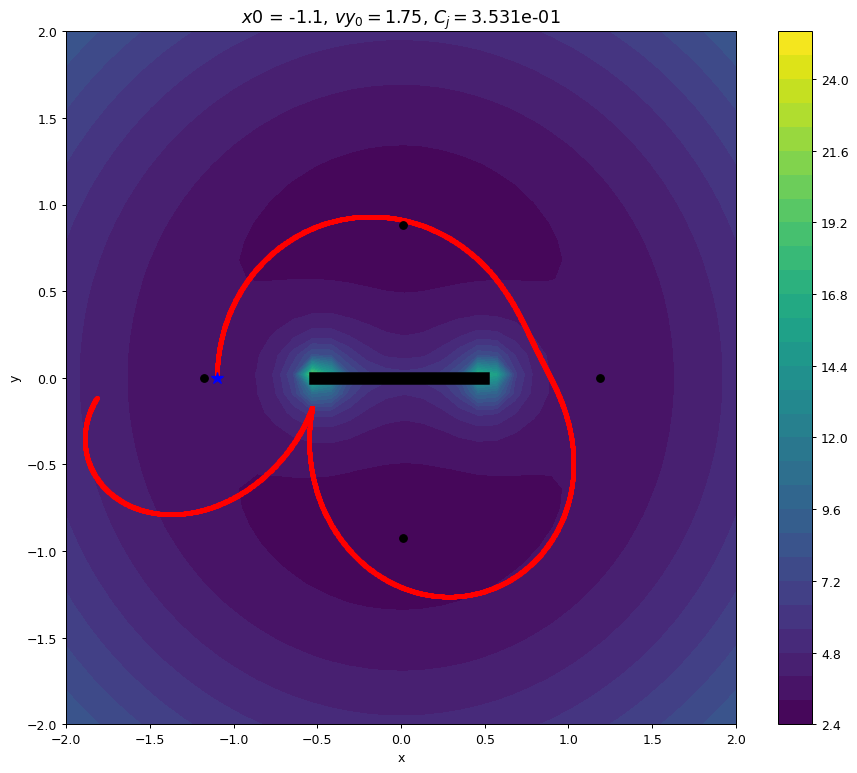

In [ ]:
#initial conditions
x0, y0, z0 = -1.1, 0, 0
vx0, vy0, vz0 = 0, 1.75, 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 5
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.3e}', fontsize = 14)

Text(0.5, 1.0, '$x0$ = 1.5, $vy_0 = -0.52$, $C_j = $3.450e+00')

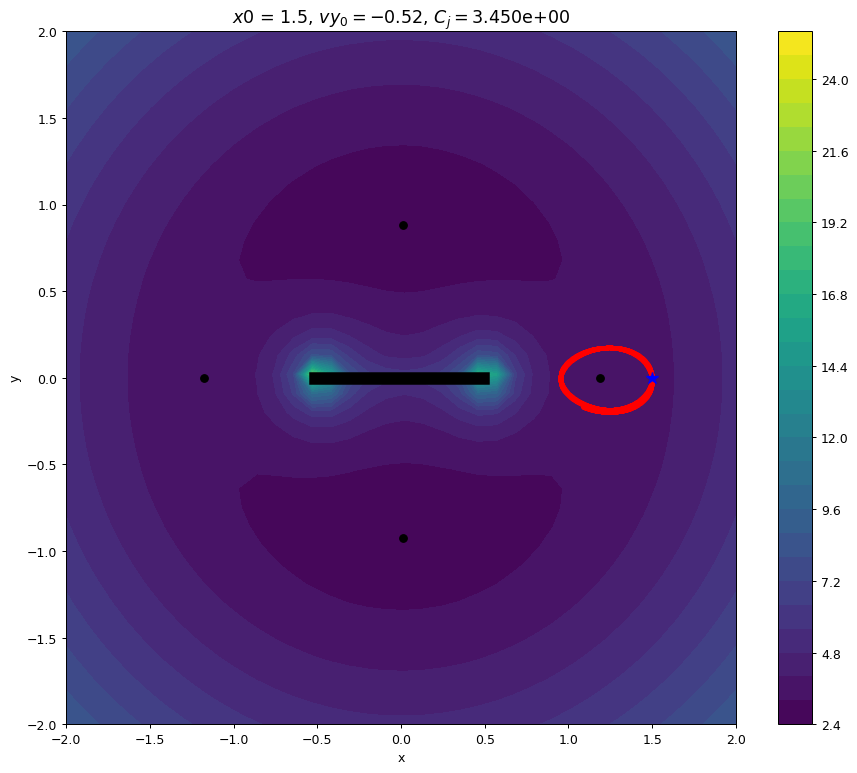

In [ ]:
#initial conditions
x0, y0, z0 = 1.5, 0, 0
vx0, vy0, vz0 = 0, -0.52, 0

Cj = jacobi_const(x0, y0, z0, l1, l2, kappa, vx0, vy0, vz0)

r0 = np.array((x0, y0, z0))
v0 = np.array((vx0, vy0, vz0))
Y0 = np.hstack((r0, v0))

# Time points
period = 1
t0, tf = 0, 3
tpoints = np.linspace(t0, tf, 3000)

# Solve ODE

sol = aster_solver(t0, tf, tpoints)

r = sol[:,:3]
v = sol[:,3:]

# Plot

fig, ax = plt.subplots(figsize=(12,10), dpi = 90)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r[:, 0], r[:, 1], "r.", label="Trajectory")
ax.plot([0+l1, 0-l2], [0, 0], color = 'black', linewidth = 10)

ax.plot(x0, y0, 'b*', markersize = 10)

ax.plot(Lag1[0], Lag1[1], 'ko')
ax.plot(Lag2[0], Lag2[1], 'ko')
ax.plot(Lag3[0], Lag3[1], 'ko')
ax.plot(Lag4[0], Lag4[1], 'ko')



surf = ax.contourf(x_mat, y_mat, effective_surf, 35)

fig.colorbar(surf)


ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

ax.set_title(f'$x0$ = {x0}, $vy_0 = {vy0}$, $C_j = ${Cj:.3e}', fontsize = 14)